In [1]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras import Model
import mplhep as hep
import matplotlib.pyplot as plt
hep.style.use("CMS")
import h5py
from sklearn.manifold import TSNE
import awkward as ak
import uproot

2026-01-11 01:26:31.474129: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-11 01:27:00.722924: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [18]:
name = ("tttune345")

path = "/eos/user/l/loshaugh/SWAN_projects/Thesis/Data/" + name + ".root"
file = uproot.open(path)
tree = file["Events"]

In [19]:
latent_space = np.array(tree["CICADA2025_TeacherLatent"].array(library='ak'))
student_scores = np.array(tree["CICADA2025_CICADAScore"].array(library="ak"))
pileup = np.array(tree["PV_npvs"].array(library='ak'))
met_pt = np.array(tree['PFMET_pt'].array(library='ak'))
energy = np.array(tree['et'].array(library='ak'))
jet_pt_1 = np.array(tree["Jet_1_pt"].array(library="ak"))

In [20]:
print(latent_space.shape)
print(student_scores.shape)
print(pileup.shape)
print(met_pt.shape)
print(energy.shape)
print(jet_pt_1.shape)

(4308, 80)
(4308,)
(4308,)
(4308,)
(4308,)
(4308,)


In [21]:
import numpy as np
from sklearn.manifold import TSNE
import plotly.express as px

nmax = 3000

tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

latent_3d = tsne.fit_transform(latent_space[:nmax,:])

In [22]:
import pandas as pd
df = pd.DataFrame({
    "x": latent_3d[:, 0],
    "y": latent_3d[:, 1],
    "z": latent_3d[:, 2],
    "energy": energy[:nmax]
})

fig = px.scatter_3d(
    df,
    x="x", y="y", z="z",
    color="energy",
    color_continuous_scale="Viridis",
    opacity=0.8,
    title = "ZB400s latent space t-SNE with energy"
)

fig.update_layout(
    scene=dict(
        xaxis_title="t-SNE 1",
        yaxis_title="t-SNE 2",
        zaxis_title="t-SNE 3"
    )
)
fig.update_traces(marker=dict(size=4))  

fig.show()


In [14]:
import pandas as pd
df = pd.DataFrame({
    "x": latent_3d[:, 0],
    "y": latent_3d[:, 1],
    "z": latent_3d[:, 2],
    "student score": student_scores[:nmax]
})

fig = px.scatter_3d(
    df,
    x="x", y="y", z="z",
    color="student score",
    color_continuous_scale="Viridis",
    opacity=0.8,
    title = "ZB400s latent space t-SNE with score"
)

fig.update_layout(
    scene=dict(
        xaxis_title="t-SNE 1",
        yaxis_title="t-SNE 2",
        zaxis_title="t-SNE 3"
    )
)
fig.update_traces(marker=dict(size=4))  

fig.show()



Energy-latent corrs for tttune345


/cvmfs/sft.cern.ch/lcg/views/LCG_105a_swan/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning:

invalid value encountered in divide

/cvmfs/sft.cern.ch/lcg/views/LCG_105a_swan/x86_64-el9-gcc13-opt/lib/python3.9/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning:

invalid value encountered in divide



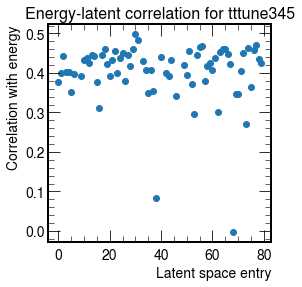



student score-latent corrs for tttune345


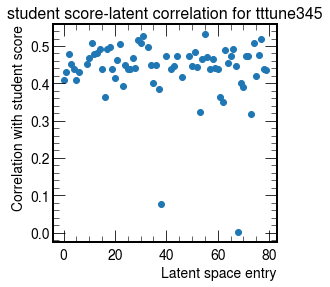



pileup-latent corrs for tttune345


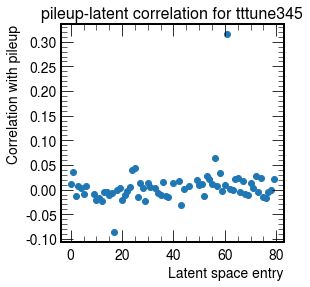



MET-latent corrs for tttune345


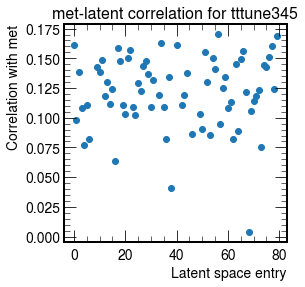



jet_pt_1-latent corrs for tttune345


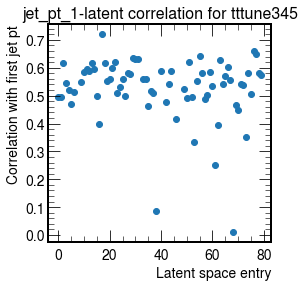

In [23]:
latents = latent_space
print("\n")
print(f"Energy-latent corrs for " + name)
corrs = []
for i in range(80):
    corr = np.corrcoef(energy,latents[:,i])
    corrs.append([i,corr[0,1]])
corrs=np.array(corrs)
plt.figure(figsize=(4,4))
plt.scatter(corrs[:,0], corrs[:,1])
plt.xlabel("Latent space entry", fontsize=14)
plt.ylabel("Correlation with energy", fontsize=14)
plt.title("Energy-latent correlation for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

print("\n")
print(f"student score-latent corrs for " + name)
corrs = []
for i in range(80):
    corr = np.corrcoef(student_scores,latents[:,i])
    corrs.append([i,corr[0,1]])
corrs=np.array(corrs)
plt.figure(figsize=(4,4))
plt.scatter(corrs[:,0], corrs[:,1])
plt.xlabel("Latent space entry", fontsize=14)
plt.ylabel("Correlation with student score", fontsize=14)
plt.title("student score-latent correlation for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

print("\n")
print(f"pileup-latent corrs for " + name)
corrs = []
for i in range(80):
    corr = np.corrcoef(pileup,latents[:,i])
    corrs.append([i,corr[0,1]])
corrs=np.array(corrs)
plt.figure(figsize=(4,4))
plt.scatter(corrs[:,0], corrs[:,1])
plt.xlabel("Latent space entry", fontsize=14)
plt.ylabel("Correlation with pileup", fontsize=14)
plt.title("pileup-latent correlation for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


print("\n")
print(f"MET-latent corrs for " + name)
corrs = []
for i in range(80):
    corr = np.corrcoef(met_pt,latents[:,i])
    corrs.append([i,corr[0,1]])
corrs=np.array(corrs)
plt.figure(figsize=(4,4))
plt.scatter(corrs[:,0], corrs[:,1])
plt.xlabel("Latent space entry", fontsize=14)
plt.ylabel("Correlation with met", fontsize=14)
plt.title("met-latent correlation for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()


print("\n")
print(f"jet_pt_1-latent corrs for " + name)
corrs = []
for i in range(80):
    corr = np.corrcoef(jet_pt_1,latents[:,i])
    corrs.append([i,corr[0,1]])
corrs=np.array(corrs)
plt.figure(figsize=(4,4))
plt.scatter(corrs[:,0], corrs[:,1])
plt.xlabel("Latent space entry", fontsize=14)
plt.ylabel("Correlation with first jet pt", fontsize=14)
plt.title("jet_pt_1-latent correlation for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

Energy-latent mutual for tttune345


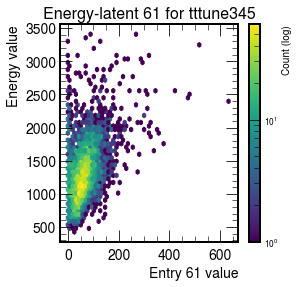

student score-latent mutual for tttune345


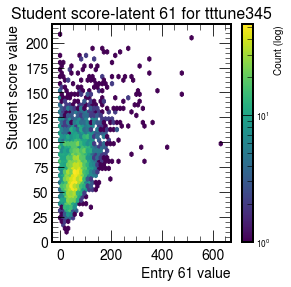

pileup-latent mutual for tttune345


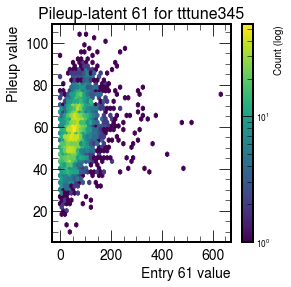

MET-latent mutual for tttune345


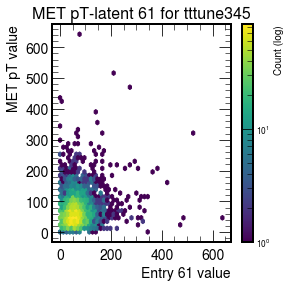

Jet 1 pt-latent mutual for tttune345


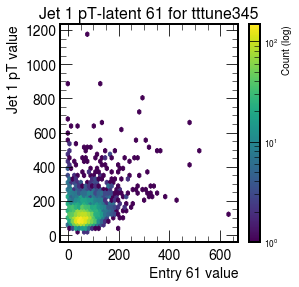

In [24]:
from sklearn.feature_selection import mutual_info_regression # use regression for continuous data
from matplotlib.colors import LogNorm

latents = latent_space
print(f"Energy-latent mutual for {name}")
'''
mutuals = mutual_info_regression(latents, energy, discrete_features=False)
mutuals=np.array(mutuals)
plt.figure(figsize=(4,4))
plt.scatter(np.arange(80), mutuals)
plt.xlabel("Latent space entry", fontsize=14)
plt.ylabel("Mutual info with energy", fontsize=14)
plt.title("Energy-latent mutual info for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
'''

plt.figure(figsize=(4,4))
plt.hexbin(latents[:,61], energy, gridsize=50,cmap='viridis',mincnt=1, norm=LogNorm())
plt.colorbar(label="Count (log)")
plt.xlabel("Entry 61 value", fontsize=14)
plt.ylabel("Energy value", fontsize=14)
plt.title("Energy-latent 61 for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

print(f"student score-latent mutual for {name}")
'''
mutuals = mutual_info_regression(latents, student_scores, discrete_features=False)
mutuals=np.array(mutuals)
plt.figure(figsize=(4,4))
plt.scatter(np.arange(80), mutuals)
plt.xlabel("Latent space entry", fontsize=14)
plt.ylabel("Mutual info with student scores", fontsize=14)
plt.title("Student score-latent mutual info for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
'''


plt.figure(figsize=(4,4))
plt.hexbin(latents[:,61], student_scores, gridsize=50,cmap='viridis',mincnt=1,norm=LogNorm())
plt.colorbar(label="Count (log)")
plt.xlabel("Entry 61 value", fontsize=14)
plt.ylabel("Student score value", fontsize=14)
plt.title("Student score-latent 61 for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

print(f"pileup-latent mutual for {name}")
'''
mutuals = mutual_info_regression(latents, pileup, discrete_features=False)
mutuals=np.array(mutuals)
plt.figure(figsize=(4,4))
plt.scatter(np.arange(80), mutuals)
plt.xlabel("Latent space entry", fontsize=14)
plt.ylabel("Mutual info with pileup", fontsize=14)
plt.title("pileup-latent mutual info for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
'''


plt.figure(figsize=(4,4))
plt.hexbin(latents[:,61], pileup, gridsize=50,cmap='viridis',mincnt=1,norm=LogNorm())
plt.colorbar(label="Count (log)")
plt.xlabel("Entry 61 value", fontsize=14)
plt.ylabel("Pileup value", fontsize=14)
plt.title("Pileup-latent 61 for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

print(f"MET-latent mutual for {name}")
'''
mutuals = mutual_info_regression(latents, met_pt, discrete_features=False)
mutuals=np.array(mutuals)
plt.figure(figsize=(4,4))
plt.scatter(np.arange(80), mutuals)
plt.xlabel("Latent space entry", fontsize=14)
plt.ylabel("Mutual info with MET", fontsize=14)
plt.title("MET-latent mutual info for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
'''


plt.figure(figsize=(4,4))
plt.hexbin(latents[:,61], met_pt, gridsize=50,cmap='viridis',mincnt=1,norm=LogNorm())
plt.colorbar(label="Count (log)")
plt.xlabel("Entry 61 value", fontsize=14)
plt.ylabel("MET pT value", fontsize=14)
plt.title("MET pT-latent 61 for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

print(f"Jet 1 pt-latent mutual for {name}")
'''
mutuals = mutual_info_regression(latents, jet_pt_1, discrete_features=False)
mutuals=np.array(mutuals)
plt.figure(figsize=(4,4))
plt.scatter(np.arange(80), mutuals)
plt.xlabel("Latent space entry", fontsize=14)
plt.ylabel("Mutual info with jet 1 pt", fontsize=14)
plt.title("jet 1 pt-latent mutual info for " + name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()
'''

plt.figure(figsize=(4,4))
plt.hexbin(latents[:,61], jet_pt_1, gridsize=50,cmap='viridis',mincnt=1,norm=LogNorm())
plt.colorbar(label="Count (log)")
plt.xlabel("Entry 61 value", fontsize=14)
plt.ylabel("Jet 1 pT value", fontsize=14)
plt.title("Jet 1 pT-latent 61 for " +name, fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [9]:
name = "glugluh2gg256"
path = "/eos/user/l/loshaugh/SWAN_projects/Thesis/Data/" + name + ".root"
file = uproot.open(path)
tree = file["Events"]
latent_space_glugluh2gg256 = np.array(tree["CICADA2025_TeacherLatent"].array(library='ak'))
jet_pt_1_glugluh2gg256 = np.array(tree["Jet_1_pt"].array(library="ak"))

name = ("singleneutrino484")
path = "/eos/user/l/loshaugh/SWAN_projects/Thesis/Data/" + name + ".root"
file = uproot.open(path)
tree = file["Events"]
latent_space_singleneutrino484 = np.array(tree["CICADA2025_TeacherLatent"].array(library='ak'))
jet_pt_1_singleneutrino484 = np.array(tree["Jet_1_pt"].array(library="ak"))

name = ("suep171")
path = "/eos/user/l/loshaugh/SWAN_projects/Thesis/Data/" + name + ".root"
file = uproot.open(path)
tree = file["Events"]
latent_space_suep171 = np.array(tree["CICADA2025_TeacherLatent"].array(library='ak'))
jet_pt_1_suep171 = np.array(tree["Jet_1_pt"].array(library="ak"))

name = ("zb478")
path = "/eos/user/l/loshaugh/SWAN_projects/Thesis/Data/" + name + ".root"
file = uproot.open(path)
tree = file["Events"]
latent_space_zb478 = np.array(tree["CICADA2025_TeacherLatent"].array(library='ak'))
jet_pt_1_zb478 = np.array(tree["Jet_1_pt"].array(library="ak"))

name = ("tttune345")
path = "/eos/user/l/loshaugh/SWAN_projects/Thesis/Data/" + name + ".root"
file = uproot.open(path)
tree = file["Events"]
latent_space_tttune345 = np.array(tree["CICADA2025_TeacherLatent"].array(library='ak'))
jet_pt_1_tttune345 = np.array(tree["Jet_1_pt"].array(library="ak"))

name = ("vbfhtotautau626")
path = "/eos/user/l/loshaugh/SWAN_projects/Thesis/Data/" + name + ".root"
file = uproot.open(path)
tree = file["Events"]
latent_space_vbfhtotautau626 = np.array(tree["CICADA2025_TeacherLatent"].array(library='ak'))
jet_pt_1_vbfhtotautau626 = np.array(tree["Jet_1_pt"].array(library="ak"))


data_dict = {
    "glugluh2gg": {"latent": latent_space_glugluh2gg256, "pt": jet_pt_1_glugluh2gg256},
    "singleneutrino": {"latent": latent_space_singleneutrino484, "pt": jet_pt_1_singleneutrino484},
    "suep": {"latent": latent_space_suep171, "pt": jet_pt_1_suep171},
    "zb": {"latent": latent_space_zb478, "pt": jet_pt_1_zb478},
    "tttune": {"latent": latent_space_tttune345, "pt": jet_pt_1_tttune345},
    "vbfhtotautau": {"latent": latent_space_vbfhtotautau626, "pt": jet_pt_1_vbfhtotautau626}
}

In [10]:
n_mix = 400 #take this from each set

# concat mse and latent
pt_mix = np.concatenate([d["pt"][:n_mix] for d in data_dict.values()]) 
latent_mix = np.concatenate([d["latent"][:n_mix] for d in data_dict.values()])

# get labels
labels_mix = list(data_dict.keys())

# create array of id's and array to convert back to original dataset
ids_mix = np.concatenate([i*np.ones(n_mix) for i in range(len(data_dict))]).astype(int)
id_to_label = {i: label for i, label in enumerate(data_dict.keys())}

print("Shuffling")

# shuffle the data
idx = np.random.permutation(len(pt_mix))
pt_mix = pt_mix[idx]
latent_mix = latent_mix[idx]
ids_mix = ids_mix[idx]

print("Beginning TSNE")

# run TSNE on mix
tsne = TSNE(n_components=2, perplexity=30)
tsne_mix = tsne.fit_transform(latent_mix)


Shuffling
Beginning TSNE


In [11]:
pt_cut = 20

mask_1 = pt_mix < pt_cut
cut_ids_mix_1 = ids_mix[mask_1]
cut_tsne_mix_1 = tsne_mix[mask_1]

mask_2 = pt_mix > pt_cut
cut_ids_mix_2 = ids_mix[mask_2]
cut_tsne_mix_2 = tsne_mix[mask_2]

In [15]:
import plotly.graph_objects as go

fig = go.Figure()

for i, label in id_to_label.items():
    data = cut_tsne_mix_1[cut_ids_mix_1 == i]
    fig.add_trace(go.Scatter3d(
        x=data[:,0],
        y=data[:,1],
        z=data[:,2],
        mode='markers',
        marker=dict(
            size=4,
            opacity=0.4
        ),
        name=label
    ))

fig.update_layout(
    scene=dict(
        xaxis_title='t-SNE 0',
        yaxis_title='t-SNE 1',
        zaxis_title='t-SNE 2'
    ),
    title='3D t-SNE of datasets, pT < ' + str(pt_cut)
)

fig.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

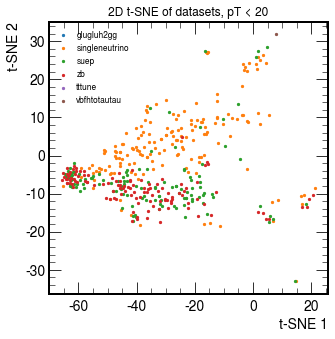

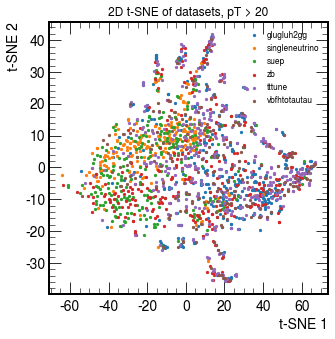

In [16]:
plt.figure(figsize=(5,5))
for i, label in id_to_label.items():
    data = cut_tsne_mix_1[cut_ids_mix_1 == i]
    plt.scatter(data[:,0], data[:,1], label = label, s=5)

plt.xlabel("t-SNE 1", fontsize=14)
plt.ylabel("t-SNE 2", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('2D t-SNE of datasets, pT < ' + str(pt_cut))
plt.legend()
plt.show()

plt.figure(figsize=(5,5))
for i, label in id_to_label.items():
    data = cut_tsne_mix_2[cut_ids_mix_2 == i]
    plt.scatter(data[:,0], data[:,1], label = label, s=5)

plt.xlabel("t-SNE 1", fontsize=14)
plt.ylabel("t-SNE 2", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('2D t-SNE of datasets, pT > ' + str(pt_cut))
plt.legend()
plt.show()


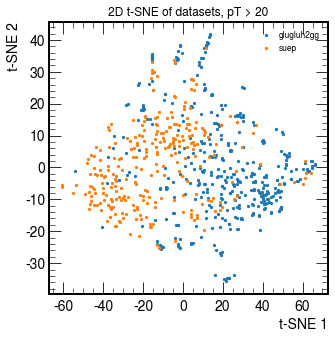

In [17]:
plt.figure(figsize=(5,5))
for i, label in id_to_label.items():
    if label in ["suep", 'glugluh2gg']:
        data = cut_tsne_mix_2[cut_ids_mix_2 == i]
        plt.scatter(data[:,0], data[:,1], label = label, s=5)

plt.xlabel("t-SNE 1", fontsize=14)
plt.ylabel("t-SNE 2", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('2D t-SNE of datasets, pT > ' + str(pt_cut))
plt.legend()
plt.show()
